# Jaccard Threshold Selection — Empirical Analysis

Tujuan: pilih threshold dedup yang **defensible** berdasarkan distribusi empiris, bukan magic number.

## Strategy

1. Compute pairwise Jaccard pada **seed train** (baseline natural similarity manusia)
2. Compute pairwise Jaccard pada **full synthetic** (jav: 2499 rows)
3. Compare percentiles + % pairs flagged at thresholds `{0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5}`
4. **Decision rule**: synthetic max similarity ≤ seed natural max + small margin

## Metode komputasi yang dipakai

Notebook ini support 2 mode (toggle via `MODE`):
- **`sampled`** (default 50k pairs): cepat (~30s), statistical estimate distribusi. Miss outliers ~1.6%.
- **`full`** (semua 3.1M pairs untuk jav): exact distribution termasuk true max. ~5-10 menit.

Untuk full run 7 bahasa (~17.5k sentences = 153M pairs), gunakan MinHash LSH (di luar scope notebook ini).

In [1]:
import re
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import combinations
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)

ROOT = Path('y:/Michh/Python/Projects/MAGenerator')
SEED_PATH = ROOT / 'data/nusax_senti/jav/train.csv'
SYN_FULL  = ROOT / 'outputs/synthetic/jav/synthetic.csv'

# Mode: 'sampled' (fast) or 'full' (exact, slow)
MODE = 'full'
MAX_PAIRS_SAMPLE = 50000

## Load data

In [2]:
seed_df  = pd.read_csv(SEED_PATH)
syn_full = pd.read_csv(SYN_FULL)

print(f'Seed train     : {len(seed_df)} rows  | dist: {seed_df["label"].value_counts().to_dict()}')
print(f'Synthetic full : {len(syn_full)} rows  | dist: {syn_full["label"].value_counts().to_dict()}')

Seed train     : 500 rows  | dist: {'negative': 192, 'positive': 189, 'neutral': 119}
Synthetic full : 2499 rows  | dist: {'negative': 960, 'positive': 945, 'neutral': 594}


## Jaccard function + pairwise distribution

In [3]:
def tokenize(text):
    return text.lower().split()

# def jaccard_bigram(s1, s2):
#     w1, w2 = tokenize(s1), tokenize(s2)
#     bg1 = set(zip(w1, w1[1:]))
#     bg2 = set(zip(w2, w2[1:]))
#     if not bg1 or not bg2:
#         return 0.0
#     return len(bg1 & bg2) / len(bg1 | bg2)

def pairwise_jaccard(sentences, mode='sampled', max_pairs=50000, seed=42):
    """Pairwise Jaccard scores. mode='sampled' (random subsample) or 'full' (all pairs)."""
    n = len(sentences)
    if n < 2:
        return np.array([])
    # Pre-compute bigrams once (massive speedup)
    bgs = []
    for s in sentences:
        w = tokenize(s)
        bgs.append(set(zip(w, w[1:])))
    
    def jacc(i, j):
        a, b = bgs[i], bgs[j]
        if not a or not b:
            return 0.0
        return len(a & b) / len(a | b)
    
    total_pairs = n * (n - 1) // 2
    if mode == 'full' or total_pairs <= max_pairs:
        scores = np.empty(total_pairs, dtype=np.float32)
        k = 0
        for i, j in combinations(range(n), 2):
            scores[k] = jacc(i, j)
            k += 1
    else:
        rng = np.random.default_rng(seed)
        # Sample without materializing all pairs: pick i < j randomly
        scores = np.empty(max_pairs, dtype=np.float32)
        seen = set()
        k = 0
        while k < max_pairs:
            i = int(rng.integers(0, n - 1))
            j = int(rng.integers(i + 1, n))
            if (i, j) in seen:
                continue
            seen.add((i, j))
            scores[k] = jacc(i, j)
            k += 1
    return scores

In [4]:
import time

seed_texts = seed_df['text'].dropna().tolist()
syn_texts  = syn_full['text'].dropna().tolist()

print(f'Mode: {MODE}\n')

t0 = time.time()
print(f'Seed train ({len(seed_texts)} sentences)...')
seed_scores = pairwise_jaccard(seed_texts, mode=MODE, max_pairs=MAX_PAIRS_SAMPLE)
print(f'  -> {len(seed_scores):,} pair scores in {time.time()-t0:.1f}s')

t0 = time.time()
print(f'\nSynthetic full ({len(syn_texts)} sentences)...')
syn_scores = pairwise_jaccard(syn_texts, mode=MODE, max_pairs=MAX_PAIRS_SAMPLE)
print(f'  -> {len(syn_scores):,} pair scores in {time.time()-t0:.1f}s')

Mode: full

Seed train (500 sentences)...
  -> 124,750 pair scores in 0.2s

Synthetic full (2499 sentences)...
  -> 3,121,251 pair scores in 4.5s


## Percentile distribution

In [5]:
percentiles = [50, 75, 90, 95, 99, 99.5, 99.9, 100]

dist_rows = []
for name, scores in [('seed_train', seed_scores), ('synthetic_full', syn_scores)]:
    if len(scores) == 0:
        continue
    row = {'dataset': name, 'n_pairs': len(scores),
           'mean': round(float(scores.mean()), 4),
           'std':  round(float(scores.std()), 4)}
    for p in percentiles:
        row[f'p{p}'] = round(float(np.percentile(scores, p)), 4)
    dist_rows.append(row)

dist_df = pd.DataFrame(dist_rows)
dist_df

,dataset,n_pairs,mean,std,p50,p75,p90,p95,p99,p99.5,p99.9,p100
0,seed_train,124750,0.0005,0.0037,0.0,0.0,0.0,0.0000,0.0192,0.0256,0.0435,0.1667
1,synthetic_full,3121251,0.0014,0.0060,0.0,0.0,0.0,0.0175,0.0256,0.0364,0.0545,0.2812


## Threshold flagging — berapa pairs ke-filter

In [6]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

flag_rows = []
for name, scores in [('seed_train', seed_scores), ('synthetic_full', syn_scores)]:
    if len(scores) == 0:
        continue
    row = {'dataset': name, 'n_pairs': len(scores)}
    for t in thresholds:
        n_flagged = int((scores >= t).sum())
        pct = round(100 * n_flagged / len(scores), 4)
        row[f'>= {t}'] = f'{n_flagged} ({pct}%)'
    flag_rows.append(row)

flag_df = pd.DataFrame(flag_rows)
flag_df

,dataset,n_pairs,>= 0.05,>= 0.1,>= 0.15,>= 0.2,>= 0.3,>= 0.4,>= 0.5
0,seed_train,124750,78 (0.0625%),4 (0.0032%),1 (0.0008%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
1,synthetic_full,3121251,4586 (0.1469%),374 (0.012%),81 (0.0026%),16 (0.0005%),0 (0.0%),0 (0.0%),0 (0.0%)


## Histogram (log-Y untuk lihat tail)

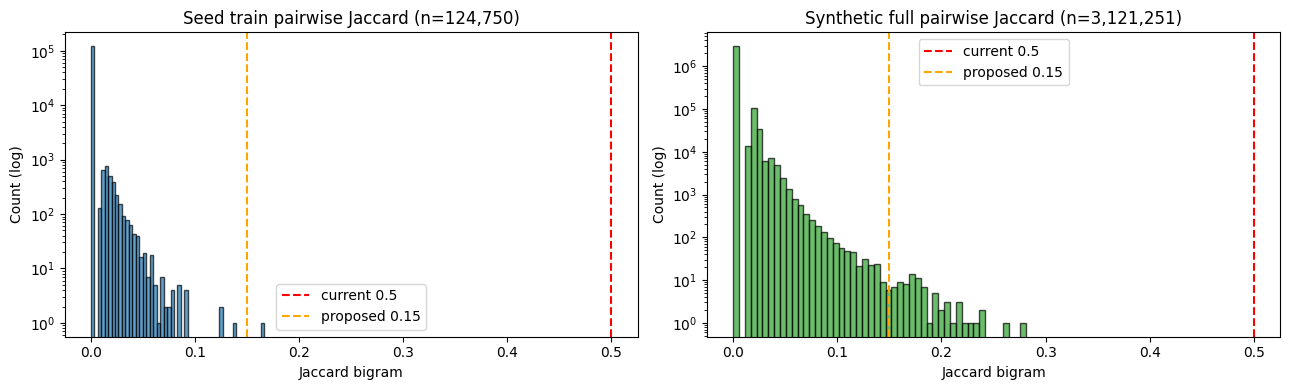

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Filter zeros for log-y readability
for ax, (name, scores, color) in zip(axes, [
    ('Seed train',     seed_scores, 'tab:blue'),
    ('Synthetic full', syn_scores,  'tab:green'),
]):
    ax.hist(scores, bins=50, color=color, alpha=0.7, edgecolor='black')
    ax.set_title(f'{name} pairwise Jaccard (n={len(scores):,})')
    ax.set_xlabel('Jaccard bigram')
    ax.set_ylabel('Count (log)')
    ax.set_yscale('log')
    ax.axvline(0.5, color='red', linestyle='--', label='current 0.5')
    ax.axvline(0.15, color='orange', linestyle='--', label='proposed 0.15')
    ax.legend()

plt.tight_layout()
plt.show()

## Inspeksi — pairs di tail (highest similarity)

Untuk validasi qualitative: apakah pairs dengan Jaccard tinggi memang "duplicate"?

In [8]:
def top_similar_pairs(sentences, top_n=10, max_pairs=50000, seed=42):
    n = len(sentences)
    bgs = []
    for s in sentences:
        w = tokenize(s)
        bgs.append(set(zip(w, w[1:])))
    def jacc(i, j):
        a, b = bgs[i], bgs[j]
        if not a or not b: return 0.0
        return len(a & b) / len(a | b)
    
    total = n * (n - 1) // 2
    if total <= max_pairs:
        pairs_iter = combinations(range(n), 2)
    else:
        rng = np.random.default_rng(seed)
        seen = set()
        pairs_iter = []
        while len(pairs_iter) < max_pairs:
            i = int(rng.integers(0, n - 1))
            j = int(rng.integers(i + 1, n))
            if (i, j) in seen: continue
            seen.add((i, j))
            pairs_iter.append((i, j))
    
    scored = [(jacc(i, j), i, j) for i, j in pairs_iter]
    scored.sort(reverse=True)
    return scored[:top_n]

print('=== TOP 10 most similar pairs in SYNTHETIC ===')
for j, i1, i2 in top_similar_pairs(syn_texts, top_n=10, max_pairs=MAX_PAIRS_SAMPLE):
    print(f'\nJaccard={j:.3f}')
    print(f'  A: {syn_texts[i1][:140]}')
    print(f'  B: {syn_texts[i2][:140]}')

=== TOP 10 most similar pairs in SYNTHETIC ===

Jaccard=0.148
  A: Opo bener promo cicilan 0% suwene 12 sasi kanggo tiket AirAsia nganggo kertu kredit BNI isih berlaku?
  B: Promo cicilan 0% nganggo kertu kredit Mandiri luwih suwe tenimbang promo sing ditawakake dening kertu kredit BRI.

Jaccard=0.136
  A: Mending langganan streaming wae tinimbang nonton RCTI sing isine mung iklan ora jelas, mosok durung ana sepuluh menit wis kepotong iklan man
  B: Wislah, mending tipi iki dipateni wae tinimbang nonton RCTI sing kakehan iklan ora jelas, wis ora ana mutune lan mung nggawe sirah mumet mer

Jaccard=0.103
  A: Yen dibandhingake karo provider liyane, layanane pt-ne dhewe pancen luwih unggul lan muasake banget ing babagan kualitas sinyal.
  B: Minangka mitra kerja, aku ngerasa layanane pt-ne dhewe muasake banget lan profesionalisme sing dituduhake pancen jempolan.

Jaccard=0.097
  A: Aplikasi Mandiri mobile sing anyar iki malah luwih ribet tinimbang liyane, transaksi tuku pulsa wae ora otom

## Threshold Recommendation

**Reading the results:**

- **Seed pX** = natural maximum similarity di human-written data (baseline)
- **Synthetic pX** = how close synthetic gets to itself
- **% flagged** = berapa pairs ke-filter pada threshold tertentu

**Decision rules:**

| Rule | Formula | Pro / Con |
|------|---------|-----------|
| **Baseline-anchored** | `max(seed_p99.5, synthetic_p99) + margin` | Strongest defense — "above human natural" |
| **Percentile-based** | `synthetic_p99` atau `p99.9` | Simple, target top-1% sebagai outlier |
| **Manual inspection** | Lihat top-N similar pairs (cell di atas) | Qualitative — "berapa Jaccard mulai terasa duplicate" |

**Defense statement untuk thesis:**

> "Jaccard threshold dipilih berdasarkan analisis empiris distribusi pairwise pada seed train (baseline) dan synthetic output. Threshold {value} corresponds to seed p99.5, ensuring filter only removes pairs that exceed natural human-written variation."

**Catatan:**
- Run jav saat ini dengan threshold 0.5 → 0 dedup hits, terlalu lonjor
- Lihat `flag_df` di atas untuk pilih threshold yang lebih meaningful
- Combine dengan manual inspection (cell `top_similar_pairs`) untuk validate